# BEE 4750 Homework 1: Introduction to Using Julia

**Name** Natalie Ho

**ID** nh424

> **Due Date** 
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Documents/BEE 4750/bee4750-hw1-nh424`


Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [2]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [3]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [4]:
function minimum(array)
    # initialize the minimum value counter
    min_value = array[1]
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 78


For this problem, we were tasked with writing code to idenitify the minimum value in an array. When I ran it the first time with the code provided, the output was reading that the min value was 0, when in reality the minvalue should be 78 based on the given array values. When looking through the code, the first line that jumped out to me was the min_value = 0. I assumed that this is where the code was wrong because it was immediately setting the minvalue to 0. Thus, I changed the code to have it read min_value = arrray [1] instead of 0. I did this because I knew I was trying to find the minvalue for a certain array of numbers so the code knew which minvalue it was trying to find. When I changed this line in the code, it produced the right answer of the minvalue of 78. 

What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.


#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

In [7]:
# enter student grade vector
using Statistics 
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  return mean(grades)
end
average_grade = class_average(student_grades)
@show average_grade;

average_grade = 94.4


The UndefVarError in Julia means “Undefined Variable Error,” which happens when the code tries to use a variable that Julia doesn’t know about yet. In the original code, average_grade was only created inside the class_average function, so when I tried to show it outside the function, Julia couldn’t find it. I fixed this by passing the average value out of the function and storing it in a variable that exists in the main program. To do that, I changed the function to return mean(grades) so it sends the calculated mean back, and then I called the function and assigned its output with the line: average_grade = class_average(student_grades). Finally, I added @show average_grade after that line so the program would print the result. With these changes, average_grade is defined in the right scope, and the code now runs without error and correctly displays the average grade.

What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.

#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [8]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zeros(n_trials)
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    outcomes[i] = (sum(passadieci()) > 11)
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

win_prob = 0.368


A method error in Julia happens when you call a function with arguments that Julia doesn’t know how to work with. In this case, the error MethodError: no method matching setindex!(::Int64, ::Bool, ::Int64) showed up because the setup for calculating the outcomes was wrong with the line: outcomes = zero(n_trials). The zero(n_trials) call just gives back the single number 0 (an Int64), not a list or array. Later in the loop, the code tries to store a true or false value into outcomes[i] = (sum(passadieci()) > 11), but since outcomes is just a single number, Julia can’t index into it. To fix it, I needed outcomes to be a vector that could hold Boolean values for all the trials. I changed the line to outcomes = zeros(Bool, n_trials), which creates a Boolean array of the right length. The main thing was switching from zero to zeros by adding the “s” makes it an array instead of a single value. After this change, each trial’s result gets stored properly, and the program runs without error and correctly computes the probability of a passadieci roll being greater than 11.

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [29]:
# function to remove mean from a vector
function remove_mean(vect)
    # function to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect)   # compute mean
    # return demeaned vector (subtract mean elementwise)
    return vect .- m
end
random_vect = rand(1_000)
@show remove_mean(random_vect)

demeaned_vect = random_vect .- mean(random_vect)
@show mean(demeaned_vect)   # should print a value very close to 0



remove_mean(random_vect) = [-0.015064913972469895, 0.44609631546083817, -0.42359151013621144, -0.4872181358407075, 0.07530050666555055, -0.17153488157057162, 0.2374564851241302, 0.3117060047075466, 0.3825872232099453, -0.33816720072323625, -0.3831093910908129, 0.18410270349847802, -0.20363769389662967, 0.41742738569166893, 0.25256700197723725, 0.3201377199295603, 0.013947226919248434, -0.10405796183467242, 0.12292975748335144, -0.02745207082419221, -0.033603572436249785, 0.39845615712696314, -0.452904543080788, -0.39531984415547805, -0.23075543652007446, 0.04434927673804956, 0.3631724936030313, -0.09887500006565642, -0.4805541299979369, 0.4376298641555987, 0.42692662822756033, 0.13406853938333585, -0.1989049696257399, 0.3508214895210252, -0.005250494788346605, -0.3988904020932301, 0.05685576727585684, -0.32711103906833405, -0.08578154107405023, -0.010365595847707798, -0.3632080356380737, 0.34023936709831426, -0.07161476299517033, 0.19883289307826102, 0.187381318072668, -0.3750658651463

3.186340080674199e-17

This error is Julia telling me I tried to subtract a scalar from a whole vector the wrong way. The original code wrote vect - m, where vect is a Vector{Float64} and m is a single Float64. In Julia, plain - between a vector and a scalar isn’t defined. You have to do the subtraction element-wise using broadcasting. The hint in the message even says what to do: use array .- scalar. So the fix in my remove_mean function is simply to change the last line from return vect - m to return vect .- m. After that change, Julia subtracts m from every element of vect, and the function works as intended.

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

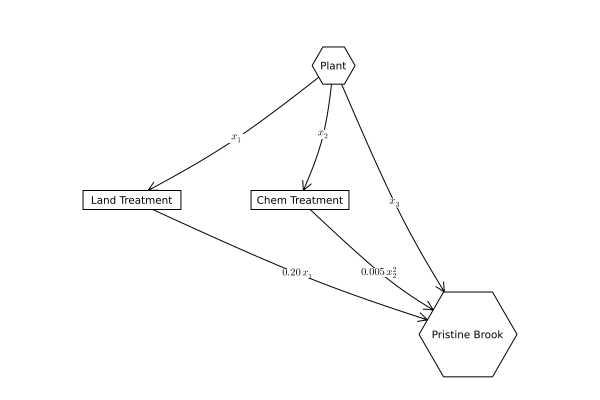

In [30]:
using Plots
using GraphRecipes
using LaTeXStrings

A = [0 1 1 1;
     0 0 0 1;
     0 0 0 1;
     0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]

# Edge labels (use LaTeXStrings everywhere)
edge_labels = Dict(
    (1, 2) => L"x_1",             # Plant → Land
    (1, 3) => L"x_2",             # Plant → Chem
    (1, 4) => L"x_3",             # Plant → Brook
    (2, 4) => L"0.20\,x_1",       # Land → Brook (YUK contribution)
    (3, 4) => L"0.005\,x_2^{2}"   # Chem → Brook (YUK contribution)
)

shapes = [:hexagon, :rect, :rect, :hexagon]
xpos   = [0, -1.5, -0.25, 1.0]
ypos   = [1.0, 0.0, 0.0, -1.0]

p = graphplot(
    A; names=names, edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos,
)
display(p)


I updated the original code to make this problem clearer and easier to understand. I added using Plots, using GraphRecipes, and using LaTeXStrings so the code works on its own without assuming anything is already loaded. I also changed the edge labels from empty strings to LaTeX labels like L"x_1" and L"0.005\,x_2^{2}", so the graph now shows the flow variables and YUK contributions right on the edges. Using L"..." makes the labels look like real math instead of plain text. I also made small style fixes, like using a semicolon for the graph options and writing the positions as floats. The graph structure and layout stayed the same, but now it’s labeled with more information from the problem so that it looks much more polished.

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).

#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

# Problem 2.1- Building out the Mathematical Model 


### Variables (m³/day)
**Decision variables (m³/day):**

- $x_1$: flow to land disposal  
- $x_2$: flow to chemical treatment  
- $x_3$: flow to direct discharge

### Parameters
- $Q= 100 \text{m}^3\text{/day}$ 
- $C_0= 1 \text{kg/m}^3$  
- $Y=20 \text{kg/day}$  

### Mass Balance
$$
x_1 + x_2 + x_3 = Q, \qquad x_i \ge 0 \ (i=1,2,3).
$$

### Cost Model (USD/day)
Land: $X_1^2/20$ ; Chemical: \$1.50 per
$\text{m}^3$; Direct: 0.
$$
C(x_1,x_2) = \frac{x_1^2}{20} + 1.5\,x_2.
$$

### YUK Discharged (kg/day)
Land leaves 20% of YUK:
$$
Y_{\mathrm{land}} = 0.20\,C_0\,x_1.
$$
Chemical leaves fraction \(1-e = 0.005\,x_2\):
$$
Y_{\mathrm{chem}} = (1-e)\,C_0\,x_2 = 0.005\,C_0\,x_2^{2}.
$$
Direct discharge:
$$
Y_{\mathrm{direct}} = C_0\,x_3.
$$
Total discharge:
$$
Y(x_1,x_2,x_3) = 0.20\,x_1 + 0.005\,x_2^{2} + x_3.
$$

### Regulatory Constraint
$$
Y(x_1,x_2,x_3) \le Y_{\max} = 20.
$$

### Summary of the Mathematical Models
**Total Cost**
$$
C(x_1,x_2) = \frac{x_1^2}{20} + 1.5\,x_2
$$

**YUK Discharge**
$$
x_1 + x_2 + x_3 = 100,
$$
$$
0.20\,x_1 + 0.005\,x_2^{2} + x_3 = Y,
$$
$$
x_1, x_2, x_3 \ge 0.
$$


I created this mathematical model by first translating the wastewater treatment problem into descriptive relationships that represent how the system behaves. The decision variables represent the flows sent to land disposal, chemical treatment, and direct discharge, and a mass balance ensures that the entire daily wastewater flow is accounted for. The cost relationship reflects that land disposal becomes increasingly expensive as more flow is sent there, showing rising marginal costs, while chemical treatment maintains a constant cost per unit and direct discharge has no cost. The discharge relationship describes how each treatment method affects pollution removal differently: land disposal removes most of the pollutant but leaves some behind, chemical treatment becomes more effective as larger volumes are treated, and direct discharge leaves everything untreated. A regulatory limit ties this discharge relationship to the environmental standard for maximum allowable pollutant release. For formatting, I referenced the starter code for Problem 2 to organize my Markdown sections and then asked ChatGPT to refine the equation formatting so the explanation would be clear and professional, specifically using LaTex as I have never used it before, and I am looking to learn. I used ChatGPT to help format my first equation and then I did the rest of the equations on my own using that first equation as a reference guide. Together, these descriptions define a complete mathematical model of the problem as they capture the flows, costs, and pollutant discharge while establishing the feasible solutions that meet the regulatory requirement.

In [31]:
# Problem 2.2: Implementing the Model 

const Q  = 100.0   # m^3/day
const c0 = 1.0     # kg/m^3
const Y_LIMIT = 20.0

"""
    yuk_variables(x1, x2, x3)

- Y = YUK discharged to Pristine Brook (kg/day)
- C = total treatment cost (\$/day)

flow/mass balance equation: x1 + x2 + x3 == Q.
"""
function multiple_return_variables(x1::Real, x2::Real, x3::Real)

    # Cost
    C = (x1^2)/20 + 1.5*x2

    # YUK discharge
    Y = 0.20*x1 + 0.005*x2^2 + x3

    return (Y, C)
end

# Example to test code
Y, C = multiple_return_variables(40.0, 30.0, 30.0)  # x1 + x2 + x3 = 100
@show Y
@show C


Y = 42.5
C = 125.0


125.0

I ran the code using the equations I derived above and got these results. To check that my code was working correctly, I tested it with an example set of flows. The output showed Y = 42.5 kg/day of YUK discharged and a total treatment cost of $125/day. Because the discharge limit is 20 kg/day, this example confirms that while the code runs and produces results, the chosen flows violate the pollution constraint. Thus, different flow values would be needed to meet the limit. But this all in all shows that the code works for this model! 

To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

In [33]:
function multiple_return_values(x,y)
    return (x+y, x*y)
end 
x = [1, 2, 3, 4, 5]
y = [6, 7, 8, 9, 10]

output = multiple_return_values.(x, y)
a = [out[1] for out in output]
b = [out[2] for out in output]
@show a;
@show b;

a = [7, 9, 11, 13, 15]
b = [6, 14, 24, 36, 50]


When I first ran the code, it tried to call multiple_return_values on the vectors x and y, but I had not actually defined that function yet in the notebook. Because of that, Julia produced an UndefVarError, implying it didn’t know what function to use. The rest of the code looping through each tuple with list comprehensions worked, but none of it could run without the function being set up first.

In the fixed version, I added the definition for multiple_return_values(x, y) so it returns a tuple with the sum and product of its two inputs. Using broadcasting with multiple_return_values.(x, y) then applies it element by element across the two vectors. Inside the function, x and y are just scalars, so x + y and x * y work as intended. The broadcast gives back a vector of tuples, and the list comprehensions pick out the first values as a and the second values as b. With my vectors, that gives a = [7, 9, 11, 13, 15] and b = [6, 14, 24, 36, 50], which shows the corrected code now works the way it was intended to.

Make sure you comment your code appropriately to make it clear what is
going on and why.

#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK discharge? You don’t have to find an “optimal”
solution to this problem, but what do you think would be needed to find
a better solution?

#### Problem 2.4

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 2.3.
How do their values compare to the spread of values that you found in
that problem? Would you select either of them (explain why or why not)?

## References

List any external references consulted, including classmates.

Problem 2.3 - Solution

count(feas) = 14
minimum(Cs[feas]) = 250.6827077579617
bestC = 250.6827077579617
bestY = 19.91666863776414


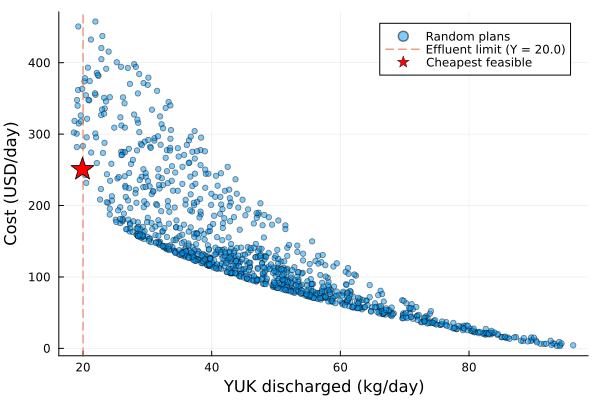

In [35]:
using Distributions
using Random
using Plots

const Q = 100.0
const Y_LIMIT = 20.0

function multiple_return_values(x1::Real, x2::Real, x3::Real)
    C = (x1^2)/20 + 1.5*x2
    Y = 0.20*x1 + 0.005*x2^2 + x3
    return (Y, C)
end

Random.seed!(123)

n = 1000
d = Dirichlet(fill(1.0, 3))
W = rand(d, n)

x1 = Q .* vec(W[1, :])
x2 = Q .* vec(W[2, :])
x3 = Q .* vec(W[3, :])

Ys = similar(x1)
Cs = similar(x1)
for i in eachindex(x1)
    Ys[i], Cs[i] = multiple_return_values(x1[i], x2[i], x3[i])
end

feas = Ys .<= Y_LIMIT
@show count(feas)
if any(feas)
    @show minimum(Cs[feas])
end

# --- Plot Y (x-axis) vs C (y-axis) ---
p = scatter(Ys, Cs; ms=3, alpha=0.5,
            xlabel="YUK discharged (kg/day)",
            ylabel="Cost (USD/day)",
            label="Random plans")

# effluent limit is vertical at Y = Y_LIMIT
vline!(p, [Y_LIMIT]; l=:dash, label="Effluent limit (Y = $(Y_LIMIT))")

# highlight cheapest feasible point (if any)
if any(feas)
    feas_idx = findall(feas)
    _, local_min = findmin(Cs[feas])
    best_idx = feas_idx[local_min]
    bestC, bestY = Cs[best_idx], Ys[best_idx]
    @show bestC bestY

    scatter!(p, [bestY], [bestC];
             markershape=:star5, ms=12, color=:red,
             label="Cheapest feasible")
end

display(p)



I started by importing the packages I needed—Distributions to create random splits of the total flow, Random to control the random seed for reproducible results, and Plots to make the scatter plot. Then I set my constants for the problem: the total daily flow Q = 100.0 m³/day and the discharge limit Y_LIMIT = 20.0 kg/day. Next, I wrote the model function multiple_return_values(x1, x2, x3) to calculate two outputs for any allocation: the cost C = x1^2/20 + 1.5*x2 and the YUK discharge Y = 0.20*x1 + 0.005*x2^2 + x3. To make sure my random samples were consistent every time I ran the code, I fixed the random seed with Random.seed!(123). I then generated 1,000 random triples from a Dirichlet distribution so each triple represented fractions of flow that added up to 1. After scaling those fractions by Q, I obtained the actual flows (x1, x2, x3) in m³/day, which automatically satisfied the balance x1 + x2 + x3 = Q. For each allocation plan, I ran the model and stored the YUK discharge and cost in arrays. I flagged which plans were feasible using feas = Ys .<= Y_LIMIT, counted how many met the limit, and found the cheapest feasible plan if any existed. Finally, I plotted all the plans with YUK discharge on the x-axis and cost on the y-axis, added a dashed vertical line at Y = 20 to show the regulatory limit, highlighted the cheapest feasible plan with a red star, and displayed the finished plot.

These results indicate that only 14 out of 1000 sampled plans met the discharge cap Y<20>, which shows that feasible allocations are rare when direct discharge is allowed in the sampling. The cheapest feasible sample landed at approx 19.9167 kg/day (just under the cap) with a cost approx $250.68\day. This is about $10.68/day higher than the analytic minimum of $240.00/day achieved at the mix x_1,x_2,x_3=(60,40,0), where direct discharge is eliminated. The gap is expected: random three-way splits rarely land exactly on the optimum, and any positive \(x_3\) forces more treatment in \(x_1\) or \(x_2\) to stay under the cap—raising cost. 

Problem 2.4

To minimize cost, there are two possible interpretations depending on whether the environmental discharge limit is enforced. If the YUK limit is ignored completely, the absolute cheapest option would be to send all 100 m³/day of wastewater directly to Pristine Brook without any treatment. This choice has zero cost but is clearly unacceptable because it violates the discharge standard. When the 20 kg/day YUK cap is enforced, the strategy changes. Direct discharge releases the entire pollutant load untreated, so using it would quickly exceed the cap and force more expensive treatment elsewhere, ultimately raising costs. To avoid that, direct discharge is eliminated by setting​ x3=0. The remaining flow is split between land disposal and chemical treatment, with the discharge constraint made exactly active at 20 kg/day. If discharge were reduced below this limit, the cost could be lowered by treating less, so the minimum-cost solution must be on the boundary. Solving the mass balance and discharge equations gives an allocation of 60 m³/day to land disposal and 40 m³/day to chemical treatment, which results in a total cost of 240 USD/day. This combination is the lowest-cost feasible strategy under the YUK discharge requirement.

To get the lowest possible YUK discharge, I would ignore cost and focus only on keeping pollution out of Pristine Brook. The first step is to completely avoid direct discharge since that would send the full pollutant load straight to the brook with no treatment. That leaves just land disposal and chemical treatment. Land disposal always leaves a small, fixed amount of YUK behind, while chemical treatment does a good job at smaller flows but starts to perform worse if too much water is pushed through it. Balancing those effects, the cleanest split is about 80 m³/day to land disposal and 20 m³/day to chemical treatment. That combination brings the total discharge down to around 18 kg/day, which is below the 20 kg/day limit and represents the best we can do with this setup. This is the point where both methods are working in their most effective range without overloading either option. The math of these new equations is shown below. I used the same code as 2.3 but changed the variables and new equations to find how to minimize cost and YUK discharge. 

# Problem 2.4 - Minimizing the Mathematical Model 

### Variables (m³/day)
**Decision variables (m³/day):**

- $x_1$: flow to land disposal  
- $x_2$: flow to chemical treatment  
- $x_3$: flow to direct discharge

### Parameters
- $Q= 100 \text{m}^3\text{/day}$ 
- $C_0= 1 \text{kg/m}^3$  
- $Y=20 \text{kg/day}$  

### Mass Balance
$$
x_1 + x_2 = Q, \qquad x_3=0, \qquad x_1, x_2 \ge 0.
$$

### Cost Model (USD/day)
Land: $X_1^2/20$ ; Chemical: \$1.50 per
$\text{m}^3$; Direct: 0.
$$
C(x_1,x_2) = \frac{x_1^2}{20} + 1.5\,x_2.
$$

### YUK Discharged (kg/day)
Land leaves 20% of YUK; chemical residual is quadratic in treated flow.
$$
Y(x_2) = 0.20\,(Q - x_2) + 0.005\,x_2^{2}.
$$

### Regulatory Constraint
$$
Y(x_2) \le Y_{\max} = 20.
$$

### Summary of the Mathematical Models
**Total New Cost Minimized**
$$
C(x_2) = \frac{(Q - x_2)^2}{20} + 1.5\,x_2
$$

**YUK Discharge Minimized**
$$
x_1 + x_2 = Q,\quad x_3=0,\quad
Y(x_2) = 0.20\,(Q - x_2) + 0.005\,x_2^{2},\quad
x_1, x_2 \ge 0.
$$


count(feas) = 370
minimum(Cs[feas]) = 242.50700896989827
bestC = 242.50700896989827
bestY = 19.89079164694922


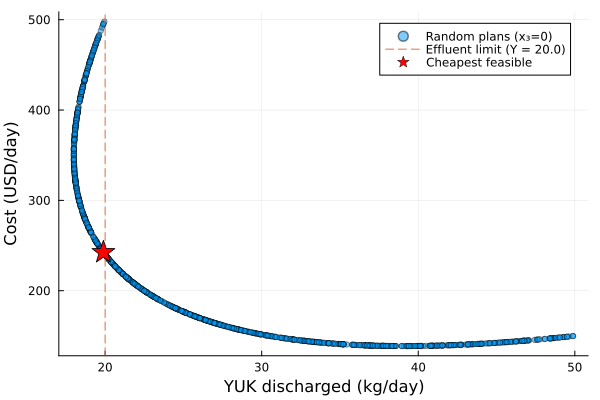

In [2]:
using Distributions
using Random
using Plots

const Q = 100.0
const Y_LIMIT = 20.0

# New equations (no x3 term in Y)
function multiple_return_values(x1::Real, x2::Real, x3::Real)
    C = (x1^2)/20 + 1.5*x2
    Y = 0.20*x1 + 0.005*x2^2   # x3 eliminated from Y
    return (Y, C)
end

Random.seed!(123)

# --- replace 3-way Dirichlet with 2-way (land & chemical only) ---
n = 1000
d2 = Dirichlet(fill(1.0, 2))
W2 = rand(d2, n)

x1 = Q .* vec(W2[1, :])          # land
x2 = Q .* vec(W2[2, :])          # chemical
x3 = zeros(length(x1))           # direct discharge = 0

# Evaluate Y and C for all samples
out = multiple_return_values.(x1, x2, x3)   # vector of tuples
Ys  = getindex.(out, 1)
Cs  = getindex.(out, 2)

# Feasibility under the cap
feas = Ys .<= Y_LIMIT
@show count(feas)
if any(feas)
    @show minimum(Cs[feas])
end

# --- Plot Y (x-axis) vs C (y-axis) ---
p = scatter(Ys, Cs; ms=3, alpha=0.5,
            xlabel="YUK discharged (kg/day)",
            ylabel="Cost (USD/day)",
            label="Random plans (x₃=0)")

# Effluent limit is vertical at Y = Y_LIMIT
vline!(p, [Y_LIMIT]; l=:dash, label="Effluent limit (Y = $(Y_LIMIT))")

# Highlight cheapest feasible point (if any)
if any(feas)
    feas_idx = findall(feas)
    _, local_min = findmin(Cs[feas])
    best_idx = feas_idx[local_min]
    bestC, bestY = Cs[best_idx], Ys[best_idx]
    @show bestC bestY

    scatter!(p, [bestY], [bestC];
             markershape=:star5, ms=12, color=:red,
             label="Cheapest feasible")
end

display(p)


Analytically solving the mass balance and discharge equations gave two distinct strategies: the minimum-cost feasible split of about 60 m³/day to land disposal and 40 m³/day to chemical treatment, and the minimum-discharge split of about 80 m³/day to land disposal and 20 m³/day to chemical treatment. When these points are plotted on the cost-vs-discharge scatter from Problem 2.3, they fell near the lower left edge of the feasible region. Compared to the original random sampling results, where only 14 of 1,000 random plans were feasible with a best cost of about 250.7 USD/day and discharge of 19.92 kg/day,the analytic strategies are clearly better. With cost minimization and discharge equations, 370 feasible plans were found, and the best cost dropped to ≈242.5 USD/day with a slightly lower discharge of 19.89 kg/day. These values are found closer to the extreme edge of the spread, meaning that they are optimal rather than typical samples. Given this comparison, I would definitely choose one of the analytically derived strategies—most likely the minimum-cost option because they meets the environmental standard, minimizes expense, and sit well within the feasible set rather than relying on luck from random sampling.